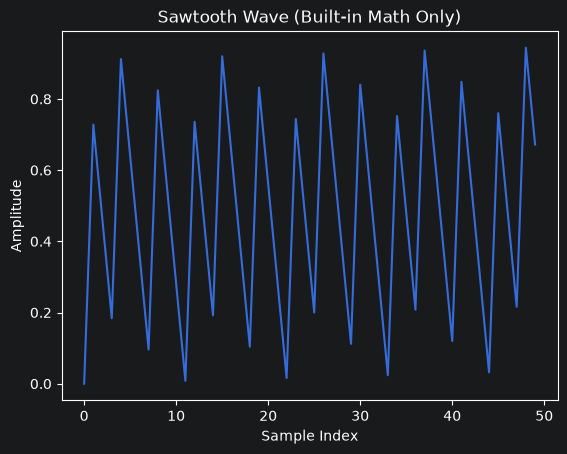

In [11]:
import math
import matplotlib.pyplot as plt  # Optional, for visualization

def generate_sawtooth(frequency=5, duration=1.0, sample_rate=44100):
    """
    Generates a sawtooth wave array using only built-in math modules.
    """
    samples = []
    total_samples = int(duration * sample_rate)

    for i in range(total_samples):
        # Calculate time for this sample
        t = i / sample_rate

        # Calculate phase: (t * freq) gives the number of cycles elapsed.
        # % 1 keeps it within [0, 1), creating the ramp.
        phase = (t * frequency) % 1.0

        # Scale to amplitude range [-1, 1] or [0, 1]
        # Standard sawtooth often goes from -1 to 1:
        # amplitude * (2 * phase - 1)
        # Or 0 to 1:
        # amplitude * phase
        value = phase

        samples.append(value)

    return samples

# Example usage for plotting
if __name__ == "__main__":
    # Generate 1 second of 5Hz wave
    wave = generate_sawtooth(frequency=728, duration=1.0, sample_rate=1000)

    # Plotting (requires matplotlib, but generation used no external libs)
    plt.plot(wave[:50])
    plt.title("Sawtooth Wave (Built-in Math Only)")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.show()

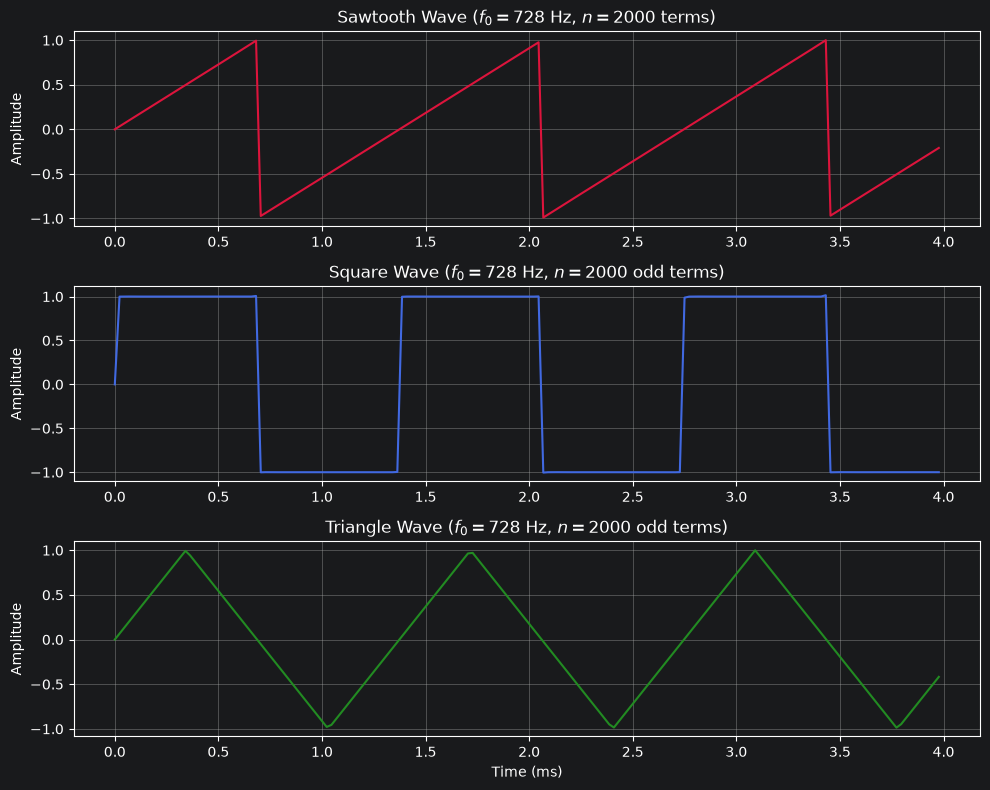

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Parameters
f0 = 728          # Fundamental frequency (Hz)
sr = 44100        # Sampling rate (Hz)
duration = 0.004  # ~3 cycles for f0 = 728 Hz
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# Number of overtones / harmonics terms to superimpose
n = 2000

# Initialize signal arrays
saw_wave = np.zeros_like(t)
square_wave = np.zeros_like(t)
triangle_wave = np.zeros_like(t)

# Step 2: Custom Fourier Series Summation
for k in range(1, n + 1):
    # Sawtooth: Summing all harmonics (k = 1, 2, 3...)
    saw_wave += ((2 / np.pi) * ((-1)**(k + 1) / k)) * np.sin(2 * np.pi * k * f0 * t)

    # Odd harmonic index multiplier (1, 3, 5, 7...)
    odd_k = 2 * k - 1

    # Square: Summing odd harmonics
    square_wave += ((4 / np.pi) * (1 / odd_k)) * np.sin(2 * np.pi * odd_k * f0 * t)

    # Triangle: Summing odd harmonics with alternating signs and quadratic decay
    triangle_wave += ((8 / (np.pi**2)) * (((-1)**(k - 1)) / (odd_k**2))) * np.sin(2 * np.pi * odd_k * f0 * t)

# Step 3: Plotting
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t * 1000, saw_wave, color='crimson', linewidth=1.5)
plt.title(f'Sawtooth Wave ($f_0 = {f0}$ Hz, $n = {n}$ terms)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t * 1000, square_wave, color='royalblue', linewidth=1.5)
plt.title(f'Square Wave ($f_0 = {f0}$ Hz, $n = {n}$ odd terms)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t * 1000, triangle_wave, color='forestgreen', linewidth=1.5)
plt.title(f'Triangle Wave ($f_0 = {f0}$ Hz, $n = {n}$ odd terms)')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

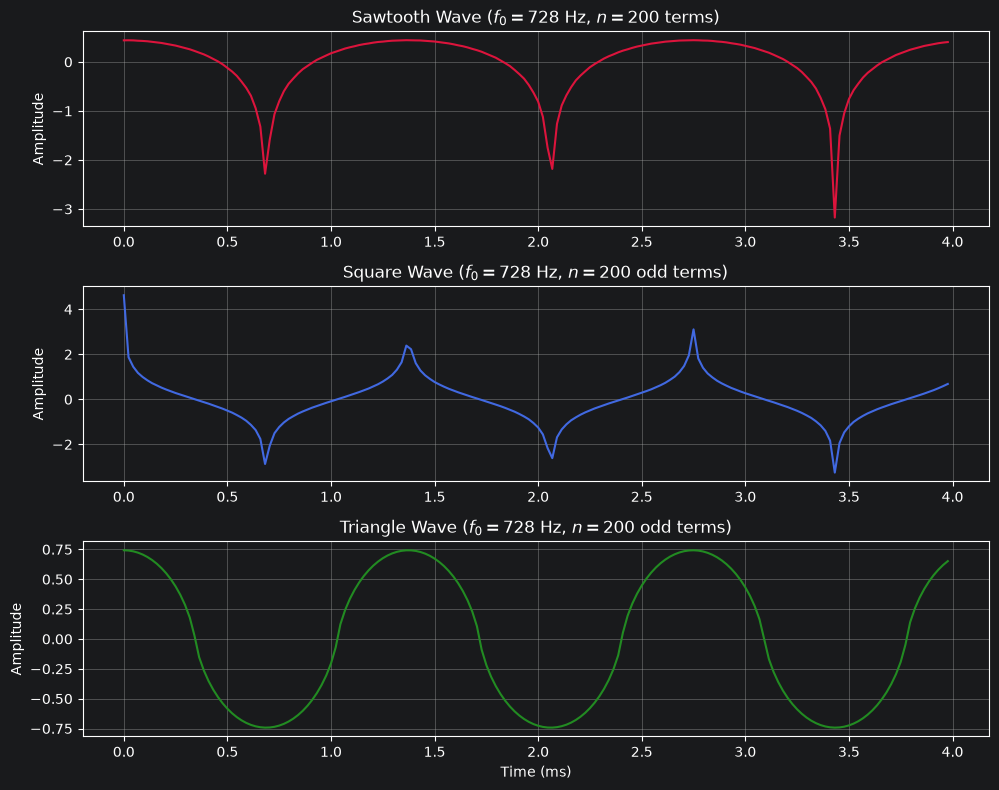

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Parameters
f0 = 728          # Fundamental frequency (Hz)
sr = 44100        # Sampling rate (Hz)
duration = 0.004  # ~3 cycles for f0 = 728 Hz
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# Number of overtones / harmonics terms to superimpose
n = 200

# Initialize signal arrays
saw_wave = np.zeros_like(t)
square_wave = np.zeros_like(t)
triangle_wave = np.zeros_like(t)

# Step 2: Custom Fourier Series Summation
for k in range(1, n + 1):
    # Sawtooth: Summing all harmonics (k = 1, 2, 3...)
    saw_wave += ((2 / np.pi) * ((-1)**(k + 1) / k)) * np.cos(2 * np.pi * k * f0 * t)

    # Odd harmonic index multiplier (1, 3, 5, 7...)
    odd_k = 2 * k - 1

    # Square: Summing odd harmonics
    square_wave += ((4 / np.pi) * (1 / odd_k)) * np.cos(2 * np.pi * odd_k * f0 * t)

    # Triangle: Summing odd harmonics with alternating signs and quadratic decay
    triangle_wave += ((8 / (np.pi**2)) * (((-1)**(k - 1)) / (odd_k**2))) * np.cos(2 * np.pi * odd_k * f0 * t)

# Step 3: Plotting
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t * 1000, saw_wave, color='crimson', linewidth=1.5)
plt.title(f'Sawtooth Wave ($f_0 = {f0}$ Hz, $n = {n}$ terms)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t * 1000, square_wave, color='royalblue', linewidth=1.5)
plt.title(f'Square Wave ($f_0 = {f0}$ Hz, $n = {n}$ odd terms)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t * 1000, triangle_wave, color='forestgreen', linewidth=1.5)
plt.title(f'Triangle Wave ($f_0 = {f0}$ Hz, $n = {n}$ odd terms)')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()